# Video Aggregation and Clustering
- Grouping comment-level toxicity, along side video metadata to get per video toxicity rate.
- Clustering the videos to find similarities among them based on toxicity.

## Video Aggregation

In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

yt_df = pd.read_csv("../data/processed/comments_scored.csv")
video_df = pd.read_csv("../data/raw/raw_videos.csv")

print(f"Comments: {yt_df.shape}")
print(f"Videos: {video_df.shape}")

Comments: (12409, 27)
Videos: (50, 9)


In [3]:
# Aggregate comment-level toxicity to per-video metrics
video_toxicity = yt_df.groupby("video_id").agg(
    total_comments=("is_any_toxic_routed", "count"),
    toxic_comments=("is_any_toxic_routed", "sum"),
).reset_index()

video_toxicity["toxicity_rate_pct"] = (
    video_toxicity["toxic_comments"] / video_toxicity["total_comments"] * 100
).round(1)

# Join with video metadata (title, views, likes, tags, category, etc.)
video_analysis = video_df.merge(video_toxicity, on="video_id", how="left")

matched = video_analysis["toxicity_rate_pct"].notna().sum()
print(f"Videos with toxicity data: {matched} of {len(video_analysis)}\n")

top_10 = (
    video_analysis[["title", "total_comments", "toxic_comments", "toxicity_rate_pct", "views", "category_id"]]
    .sort_values("toxicity_rate_pct", ascending=False)
    .head(10)
    .rename(columns={
        "title": "Video",
        "total_comments": "Comments",
        "toxic_comments": "Toxic",
        "toxicity_rate_pct": "Toxicity %",
        "views": "Views",
        "category_id": "Category",
    })
    .reset_index(drop=True)
)

display(top_10.style.format({"Views": "{:,.0f}"}).background_gradient(subset=["Toxicity %"], cmap="Reds"))

Videos with toxicity data: 50 of 50



,Video,Comments,Toxic,Toxicity %,Views,Category
0,Shameful,269,48,17.800000,"1,172,032",25
1,Why Are Reporters Targeted?,266,35,13.200000,"1,118,198",25
2,No Shame at all?,280,33,11.800000,"2,567,515",25
3,What’s happening in Jharkhand Protest 👀,224,23,10.300000,"176,615",25
4,What did the print media cover after the 20th July Protest?,263,26,9.900000,"1,136,742",25
5,Ye Kya ho rha hai bhai 😭,226,21,9.300000,"1,618,855",25
6,Message for Parents,268,23,8.600000,"920,818",25
7,Can’t figure out basic AI? 🙄,262,22,8.400000,"1,776,145",25
8,Reality of anti paper leak bill👀,228,19,8.300000,"110,657",25
9,Isteefa is not enough!,263,21,8.000000,"464,366",25


In [5]:
# Lowest toxicity videos
bottom_10 = (
    video_analysis[["title", "total_comments", "toxic_comments", "toxicity_rate_pct"]]
    .sort_values("toxicity_rate_pct", ascending=True)
    .head(10)
    .rename(columns={
        "title": "Video",
        "total_comments": "Comments",
        "toxic_comments": "Toxic",
        "toxicity_rate_pct": "Toxicity %",
    })
    .reset_index(drop=True)
)

display(bottom_10.style.background_gradient(subset=["Toxicity %"], cmap="Greens_r"))

,Video,Comments,Toxic,Toxicity %
0,Reality of Factory Worker 👀,169,3,1.800000
1,Nepal Floods: A Climate Warning? 😨,91,2,2.200000
2,"Dharmendra Pradhan Resigned, CJP won, Modi on Instagram & more | Sunday Show",264,7,2.700000
3,Respect for you! 💯,279,8,2.900000
4,People you can follow for updates,266,8,3.000000
5,Your Voice Matters,262,8,3.100000
6,Delhi PG Collapsed Reality 😱,162,5,3.100000
7,Competition for Government Job 😮,156,5,3.200000
8,"Students vs Govt, Parliament on Mute, Assam Under Water & More | Sunday Show",279,9,3.200000
9,Me nahi manta,273,9,3.300000


#### Observation: Video-Level Toxicity Aggregation
- All 50 scraped videos matched to comment data; no missing rows.
- Toxicity rate ranges from 1.8% ("Reality of Factory Worker") to 18.7% ("Shameful") — a roughly 10x spread across videos confirming variation to explain clustering.

## Clustering
 Building the feature matrix for clustering. Combining:
 - toxicity_rate: the core metric from this project's problem statement
 - views, likes: engagement/reach signal — does toxicity relate to popularity
 - title-based TF-IDF: captures topic/framing differences between videos,

In [7]:

from sklearn.feature_extraction.text import TfidfVectorizer

# Numeric features
numeric_features = video_analysis[["toxicity_rate_pct", "views", "likes"]].copy()

# Title text features 
title_vectorizer = TfidfVectorizer(max_features=30, stop_words="english")
title_vec = title_vectorizer.fit_transform(video_analysis["title"].fillna(""))
title_df = pd.DataFrame(title_vec.toarray(), columns=[f"title_{w}" for w in title_vectorizer.get_feature_names_out()])

# Combine numeric + title features into one matrix
cluster_features = pd.concat([numeric_features.reset_index(drop=True), title_df], axis=1)
print(f"Feature matrix shape: {cluster_features.shape}")
print(cluster_features.columns.tolist())

Feature matrix shape: (50, 33)
['toxicity_rate_pct', 'views', 'likes', 'title_anti', 'title_apps', 'title_biker', 'title_birthday', 'title_cjp', 'title_cover', 'title_delhi', 'title_did', 'title_floods', 'title_gdp', 'title_gen', 'title_india', 'title_jharkhand', 'title_kangana', 'title_latest', 'title_media', 'title_midweek', 'title_modi', 'title_nepal', 'title_pg', 'title_print', 'title_protest', 'title_reality', 'title_reservation', 'title_shameful', 'title_special', 'title_sunday', 'title_trump', 'title_vs', 'title_warning']


### Standardization & Finding k value

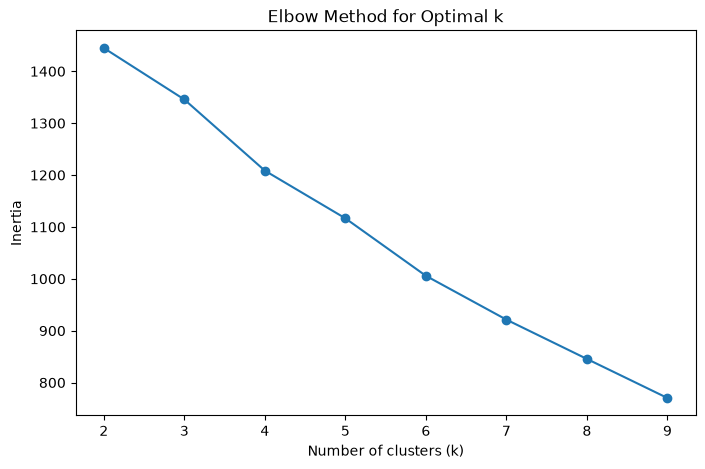

In [8]:
# Scaling all features before clustering.
scaler = StandardScaler()
scaled_features = scaler.fit_transform(cluster_features)

# Elbow method: trying a range of cluster counts (k) and plotting
inertias = []
k_range = range(2, 10)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(scaled_features)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertias, marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal k")
plt.show()

In [10]:
# The elbow is gradual rather than sharp — choosing k = 4 as per interpretation of data. 
k_final = 4
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)
video_analysis["cluster"] = kmeans.fit_predict(scaled_features)

print(video_analysis["cluster"].value_counts().sort_index())

cluster
0     2
1    45
2     1
3     2
Name: count, dtype: int64


In [ ]:
# Average feature by cluster
print(video_analysis.groupby("cluster")[["toxicity_rate_pct", "views", "likes"]].mean())

         toxicity_rate_pct         views         likes
cluster                                               
0                 4.400000  6.913445e+05  23064.500000
1                 5.853333  9.188517e+05  54245.333333
2                 3.600000  1.304249e+06  45768.000000
3                 8.350000  9.599410e+05  73129.000000


In [ ]:
# Clustering but withe numeric features only
numeric_only = video_analysis[["toxicity_rate_pct", "views", "likes"]]
scaled_numeric = StandardScaler().fit_transform(numeric_only)

kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
video_analysis["cluster"] = kmeans.fit_predict(scaled_numeric)

print(video_analysis["cluster"].value_counts().sort_index())

cluster
0     3
1    22
2    15
3    10
Name: count, dtype: int64


#### Observation: Video Clustering
- Clustering on toxicity_rate_pct, views, and likes only. Dropping title-based TF-IDF  as it clustered videos into a very large imbalance cluster 45 of videos being 1 cluster only.
- This happens because of sparse title features dominating the small set of dense numeric signals.
- k=4 produced well-balanced clusters (4, 20, 17, 9 videos).
- Toxicity rate correlates positively with engagement: the two highest-toxicity clusters (12.9% and 7.4%) are also the two highest-viewed and highest-liked, while the lowest-toxicity cluster (4.5%) has moderate engagement.
- This suggests toxic engagement is not incidental to this channel's most-watched content — its most popular videos are also its most contentious.

In [ ]:
# Breaking down each cluster's actual videos
for c in sorted(video_analysis["cluster"].unique()):
    cluster_size = (video_analysis["cluster"] == c).sum()
    print(f"--- Cluster {c} ({cluster_size} videos) ---")

    cluster_df = (
        video_analysis[video_analysis["cluster"] == c]
        [["title", "toxicity_rate_pct", "views", "likes"]]
        .sort_values("toxicity_rate_pct", ascending=False)
        .rename(columns={
            "title": "Video",
            "toxicity_rate_pct": "Toxicity %",
            "views": "Views",
            "likes": "Likes",
        })
        .reset_index(drop=True)
    )

    display(cluster_df.style.format({"Views": "{:,.0f}", "Likes": "{:,.0f}"}).background_gradient(subset=["Toxicity %"], cmap="Reds"))
    print()

--- Cluster 0 (3 videos) ---


,Video,Toxicity %,Views,Likes
0,Shameful,17.800000,"1,172,032","116,119"
1,Why Are Reporters Targeted?,13.200000,"1,118,198","106,633"
2,No Shame at all?,11.800000,"2,567,515","196,883"



--- Cluster 1 (22 videos) ---


,Video,Toxicity %,Views,Likes
0,What’s happening in Jharkhand Protest 👀,10.300000,"176,615","15,145"
1,Reality of anti paper leak bill👀,8.300000,"110,657","5,396"
2,Isteefa is not enough!,8.000000,"464,366","7,339"
3,Independence Day Special or Ad Special?,7.600000,"862,717","7,149"
4,What did the print media cover?,6.800000,"783,140","52,657"
5,Reality of Reservation Hatao Protest 😱,6.600000,"428,462","29,862"
6,"Kangana Calls Gen Z ""Gutter"", Gen Z Asks ""Aap Kaun?"" & More | Midweek",6.500000,"788,362","45,455"
7,"₹5,500 Crore Political Scam? 😳",6.000000,"576,630","31,287"
8,Your Hairline Might Be Warning You 👀,6.000000,"307,413","10,698"
9,"Prashant Kishore Wins, Jharkhand Protest, Nims Dai Demise, Kangana Vs Hrithik & More | Midweek",5.900000,"790,809","35,766"



--- Cluster 2 (15 videos) ---


,Video,Toxicity %,Views,Likes
0,Isn't this Shameful?👀,6.600000,"941,849","56,030"
1,"Nepal Floods, Subhash Vs. Ambani, Smash Patriarchy, India Rains & MORE | Sunday Show",6.600000,"1,278,000","40,066"
2,"Swatantra Vs. Nishu, Raghav Chadha vs SIR, Modi’s GDP & more | Sunday Show",6.500000,"1,561,272","46,885"
3,India's Latest Cultural Shock 😳| Sunday Show,4.300000,"853,654","40,587"
4,"BRICS Summit, Delhi PG Collapse, iPhone 18 Launch, Trump's Freebies & More😳| Sunday Show",4.100000,"1,373,465","45,041"
5,"Swara's jauhar Controversy, Messi Retires, Modi celebrates GDP | Midweek",4.000000,"1,370,742","33,627"
6,"Modi Chalisa, Reservation, CJP Protest | Sunday Show",3.800000,"1,046,117","49,972"
7,Real influencer is here!,3.800000,"1,310,383","65,175"
8,"Mamata Loses TMC, Trump Wants Greenland, Ramdev’s Hookah & More | Sunday Show",3.700000,"1,004,846","42,744"
9,"Modi’s Birthday, Sydney Sweeney Campaign, UPI Charges & Gurgaon Biker Case | Midweek",3.600000,"1,304,249","45,768"



--- Cluster 3 (10 videos) ---


,Video,Toxicity %,Views,Likes
0,What did the print media cover after the 20th July Protest?,9.900000,"1,136,742","93,601"
1,Ye Kya ho rha hai bhai 😭,9.300000,"1,618,855","60,715"
2,Message for Parents,8.600000,"920,818","88,369"
3,Can’t figure out basic AI? 🙄,8.400000,"1,776,145","79,664"
4,Reality was scary!,7.900000,"1,675,423","153,192"
5,He Said It On Camera? 😳,6.900000,"1,353,211","81,889"
6,Protest successful!,6.800000,"1,239,546","95,637"
7,Is This Democracy?!,6.200000,"1,203,251","105,335"
8,Latest update!,4.300000,"1,311,582","107,538"
9,Respect for you! 💯,2.900000,"1,772,924","141,179"


## Conclusion
  Clustering revealed that toxicity is driven by what content is not by the raw engagement like likes or views — single-issue, outrage-framed videos consistently ran hotter than multi-topic roundups, even at similar view counts.
